In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

Aqui solo estamos diciendo con que vamos a trabajar la parte 1

In [3]:
# activos
tickers = ["MELI", "REGN", "B"]

# fechas
train_start = "2024-09-17"
train_end = "2025-09-16"

test_start = "2025-09-17"
test_end = "2026-09-17"

# capital inicial
capital = 1_000_000

# tasa libre de riesgo esta utilizada de acuerdo a Treassury de EEU
rf = 0.036

# dias bursatiles
dias = 252

# parametros del algoritmo genetico
population_size = 100
generations = 200
mutation_rate = 0.20
elite_size = 5

# para obtener los mismos resultados aleatorios
np.random.seed(42)

2. descargar precios y calcular rendimeintos  Obteniendolos con pct_change()


In [4]:
# descargamos un dia extra porque yfinance no incluye la fecha "end"
end_download = "2026-09-18"

data = yf.download(
    tickers,
    start=train_start,
    end=end_download,
    auto_adjust=True,
    progress=False
)

# tomamos los precios de cierre ajustados
prices = data["Close"]

# ordenamos las columnas
prices = prices[tickers]

# eliminamos filas con datos faltantes
prices = prices.dropna()

# calculamos rendimientos simples diarios
returns = prices.pct_change().dropna()

returns.head()

Ticker,MELI,REGN,B
Date,,,
2024-09-18,0.013682,-0.006924,-0.020508
2024-09-19,0.003215,0.009993,0.008474
2024-09-20,-0.002678,-0.004486,0.007415
2024-09-23,-0.000532,-0.046331,-0.008341
2024-09-24,0.003981,-0.042125,0.010886


3. Separara Train y Test

**Train** sirve para encontrar los pesos (W) DE MELI, REGN Y B  **Test** sirve para  ver que habria ocurrido despues, utilizando esos mismos precios 

In [5]:
train = returns.loc[train_start:train_end]

test = returns.loc[test_start:test_end]

print("Observaciones TRAIN:", len(train))
print("Observaciones TEST:", len(test))

print("\nTRAIN:")
print(train.index.min(), "a", train.index.max())

print("\nTEST:")
print(test.index.min(), "a", test.index.max())

Observaciones TRAIN: 249
Observaciones TEST: 252

TRAIN:
2024-09-18 00:00:00 a 2025-09-16 00:00:00

TEST:
2025-09-17 00:00:00 a 2026-09-17 00:00:00


4.  **Funciones financieras** sacamos medias y covarianzas utilizando  unicamente TRAIN: 

las funciones que se vana  realizar a continuacion  representan lo siguiente: 

 

$R_p = w^\top \mu$

$\sigma_p = \sqrt{w^\top \Sigma w}$

$Sharpe = \frac{R_p - R_f}{\sigma_p}$




 

In [6]:
mean_returns = train.mean()
cov_matrix = train.cov()


def portfolio_return(weights):
    
    annual_return = np.dot(weights, mean_returns) * dias
    
    return annual_return


def portfolio_volatility(weights):
    
    variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    
    volatility = np.sqrt(variance) * np.sqrt(dias)
    
    return volatility


def sharpe_ratio(weights):
    
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    
    sharpe = (ret - rf) / vol
    
    return sharpe

5. Semivarianza
Ahora medimos solamente los rendimeintos negativos. la logica coincide  en calcular los rendimientos del portafolio  y quedarnos con las desviaciones que estas por debajo de la **frontera de MARKOWITS** que en nuestro caso es 0

In [7]:
# medimos los rendimienot negativos 
def semivariance(weights):
    
    portfolio_returns = np.dot(train, weights)
    
    downside = np.minimum(portfolio_returns, 0)
    
    semi = np.mean(downside ** 2)
    
    return semi

6. Algoritmo genettico.
Aqui empieza realmente nuestra heuristica

In [ ]:
# ALGORITMO GENETICO    
def crear_poblacion():
    
    poblacion = []
    
    for i in range(population_size):
        
        weights = np.random.random(3)
        
        # hacemos que los pesos sumen 1
        weights = weights / weights.sum()
        
        poblacion.append(weights)
    
    return np.array(poblacion)
## CADA INDIVIDUO ES UN PORTAFOLIO


# seleccion 
def seleccionar(poblacion, fitness):
    
    candidatos = np.random.choice(len(poblacion), 3, replace=False)
    
    mejor = candidatos[np.argmax(fitness[candidatos])]
    
    return poblacion[mejor]
## ELIJIMOS TRES PORTAFOLIOS ALEATORIOS  Y DEJAMOS QUE 
# PASE EL QUE TENGA MEJOR FITNESS


# Crossover, mezclamos dos portafolios
def crossover(padre1, padre2):
    
    alpha = np.random.random()
    
    hijo = alpha * padre1 + (1 - alpha) * padre2
    
    return hijo

# mutacion 
def mutacion(weights):
    
    if np.random.random() < mutation_rate:
        
        cambio = np.random.normal(0, 0.05, 3)
        
        weights = weights + cambio
        
        # no permitimos pesos negativos
        weights = np.clip(weights, 0, 1)
        
        # hacemos que vuelvan a sumar 1
        weights = weights / weights.sum()
    
    return weights

Ahora junatmos  todo, basicamente aqui es el corazon de todo lo anterior.

In [9]:
def algoritmo_genetico(fitness_function):
    
    poblacion = crear_poblacion()
    
    history = []
    
    for generation in range(generations):
        
        # calculamos fitness
        fitness = np.array([
            fitness_function(weights)
            for weights in poblacion
        ])
        
        # ordenamos de mejor a peor
        orden = np.argsort(fitness)[::-1]
        
        poblacion = poblacion[orden]
        fitness = fitness[orden]
        
        # guardamos el mejor resultado
        history.append(fitness[0])
        
        # conservamos los mejores
        nueva_poblacion = list(poblacion[:elite_size])
        
        # creamos nuevos individuos
        while len(nueva_poblacion) < population_size:
            
            padre1 = seleccionar(poblacion, fitness)
            padre2 = seleccionar(poblacion, fitness)
            
            hijo = crossover(padre1, padre2)
            hijo = mutacion(hijo)
            
            nueva_poblacion.append(hijo)
        
        poblacion = np.array(nueva_poblacion)
    
    
    # calculamos fitness una ultima vez
    fitness = np.array([
        fitness_function(weights)
        for weights in poblacion
    ])
    
    mejor = poblacion[np.argmax(fitness)]
    
    return mejor, history

7. Econtrar Maximo de Sharpe 

In [10]:
# ENCONTAR MAXIMO DE SHARPE 
weights_sharpe, history_sharpe = algoritmo_genetico(
    sharpe_ratio)

print("Pesos Máximo Sharpe:")
print(weights_sharpe)

print("\nSharpe:")
print(sharpe_ratio(weights_sharpe))

for ticker, weight in zip(tickers, weights_sharpe):
    print(ticker, round(weight * 100, 2), "%")


Pesos Máximo Sharpe:
[2.14946500e-01 9.31791811e-18 7.85053500e-01]

Sharpe:
1.2245759613351699
MELI 21.49 %
REGN 0.0 %
B 78.51 %


8. MINIMA SEMIVARIANZA 
es importante recordar nuetra restriccion, pues no queremos minimizar el riesgo a costa de obtener cualquier rendimiento , primero calculamos el rendimiento del portafolio **equiponderado**

In [11]:
#minima semivarianza de acuerdoi a nuestro perfìl "No queremos minimizar el riesgo a costa de obtener cualquier rendimeinto"
equal_weights = np.array([1/3, 1/3, 1/3])

target_return = portfolio_return(equal_weights)

print("Target return:", target_return)



# ahora hacemos nuestro fitness 
def fitness_semivariance(weights):
    
    ret = portfolio_return(weights)
    semi = semivariance(weights)
    
    # penalizamos si no alcanza el rendimiento minimo
    if ret < target_return:
        return -1000
    
    # como el algoritmo maximiza fitness,
    # usamos el negativo de la semivarianza
    return -semi

# ahora si optimizamos 
weights_semi, history_semi = algoritmo_genetico(
    fitness_semivariance
)

print("Pesos Mínima Semivarianza:")

for ticker, weight in zip(tickers, weights_semi):
    print(ticker, round(weight * 100, 2), "%")



Target return: 0.008601664389558401
Pesos Mínima Semivarianza:
MELI 29.75 %
REGN 20.98 %
B 49.28 %


 Si el portafolio no alcanza el rendimeinto minimo exigido , recibe un **fitness** muy mal .


 Ahora veremos la composicion de nuestros tres portafolios.
 1. **Maximo de Sharpe**
 2. **Minima semivarianza**
 3. **Equiponderado**

In [12]:
#nuestro tres portafolio 
portfolios = {
    "Maximo Sharpe": weights_sharpe,
    "Minima Semivarianza": weights_semi,
    "Equiponderado": equal_weights
}
portfolios 

# YA TENEMOS EXACTAMENTE LAS TRES ESTRATEGIAS QUE QUERIAMOS COMPROBAR 

{'Maximo Sharpe': array([2.14946500e-01, 9.31791811e-18, 7.85053500e-01]),
 'Minima Semivarianza': array([0.29748215, 0.20976234, 0.49275552]),
 'Equiponderado': array([0.33333333, 0.33333333, 0.33333333])}

10. convertimos pesos a dólares 

In [13]:
# convertir pesos a dolares 
for name, weights in portfolios.items():
    
    print("\n", name)
    
    for ticker, weight in zip(tickers, weights):
        
        allocation = weight * capital
        
        print(
            ticker,
            round(weight * 100, 2), "%",
            " = $",
            round(allocation, 2))


 Maximo Sharpe
MELI 21.49 %  = $ 214946.5
REGN 0.0 %  = $ 0.0
B 78.51 %  = $ 785053.5

 Minima Semivarianza
MELI 29.75 %  = $ 297482.15
REGN 20.98 %  = $ 209762.34
B 49.28 %  = $ 492755.52

 Equiponderado
MELI 33.33 %  = $ 333333.33
REGN 33.33 %  = $ 333333.33
B 33.33 %  = $ 333333.33


11 Backtesting
Ahora utilizamos  **TEST**, que hasta ahora no lo habiamos utilizado hasta optimizar.

In [14]:
# es necesario sacar el backtesting 
portfolio_test_returns = pd.DataFrame()

for name, weights in portfolios.items():
    
    portfolio_test_returns[name] = np.dot(test, weights)

    # y calculamos como habra  valido nuestro millon 
    portfolio_values = capital * (
    1 + portfolio_test_returns
).cumprod()

portfolio_values.tail()


,Maximo Sharpe,Minima Semivarianza,Equiponderado
247,1.381494e+06,1.299870e+06,1.251730e+06
248,1.350907e+06,1.286399e+06,1.246961e+06
249,1.346760e+06,1.269400e+06,1.223730e+06
250,1.344751e+06,1.269599e+06,1.224963e+06
251,1.370757e+06,1.288485e+06,1.240507e+06


12. Funcion para las metricas 

aqui estamos utilizando MAR=0(rendimeinto minimo aceptablel) es decir consideramos desfavorable cualquier dia en el que el portafolio tenga un rendimeinto negativo 

In [15]:
# funcion para las metricas 
def metricas(returns):
    
    cumulative_return = (1 + returns).prod() - 1
    
    annual_return = returns.mean() * dias
    
    volatility = returns.std() * np.sqrt(dias)
    
    sharpe = (annual_return - rf) / volatility
    
    
    # downside
    downside_returns = np.minimum(returns, 0)
    
    downside_deviation = (
        np.sqrt(np.mean(downside_returns ** 2))
        * np.sqrt(dias)
    )
    
    
    # Sortino con MAR = 0
    sortino = annual_return / downside_deviation
    
    
    # drawdown
    wealth = (1 + returns).cumprod()
    
    running_max = wealth.cummax()
    
    drawdown = wealth / running_max - 1
    
    max_drawdown = drawdown.min()
    
    
    return {
        "Rendimiento": cumulative_return,
        "Rendimiento anual": annual_return,
        "Volatilidad": volatility,
        "Sharpe": sharpe,
        "Downside": downside_deviation,
        "Sortino": sortino,
        "Max Drawdown": max_drawdown
    }

Tabla final 



In [16]:
resultados = []

for name, weights in portfolios.items():
    
    m = metricas(portfolio_test_returns[name])
    
    final_value = portfolio_values[name].iloc[-1]
    
    
    resultados.append({
        
        "Estrategia": name,
        
        "Peso MELI": weights[0],
        "Peso REGN": weights[1],
        "Peso Barrick": weights[2],
        
        "USD MELI": weights[0] * capital,
        "USD REGN": weights[1] * capital,
        "USD Barrick": weights[2] * capital,
        
        **m,
        
        "Capital Final": final_value,
        "Ganancia USD": final_value - capital
    })


resultados = pd.DataFrame(resultados)

resultados

,Estrategia,Peso MELI,Peso REGN,Peso Barrick,USD MELI,USD REGN,USD Barrick,Rendimiento,Rendimiento anual,Volatilidad,Sharpe,Downside,Sortino,Max Drawdown,Capital Final,Ganancia USD
0,Maximo Sharpe,0.214947,9.317918e-18,0.785053,214946.500294,9.317918e-12,785053.499706,0.370757,0.397238,0.404115,0.893899,0.281864,1.409324,-0.295746,1.370757e+06,370756.941102
1,Minima Semivarianza,0.297482,2.097623e-01,0.492756,297482.149799,2.097623e+05,492755.515056,0.288485,0.298912,0.301576,0.871793,0.204742,1.459945,-0.260575,1.288485e+06,288485.116099
2,Equiponderado,0.333333,3.333333e-01,0.333333,333333.333333,3.333333e+05,333333.333333,0.240507,0.250430,0.264615,0.810347,0.176046,1.422523,-0.254061,1.240507e+06,240507.156895


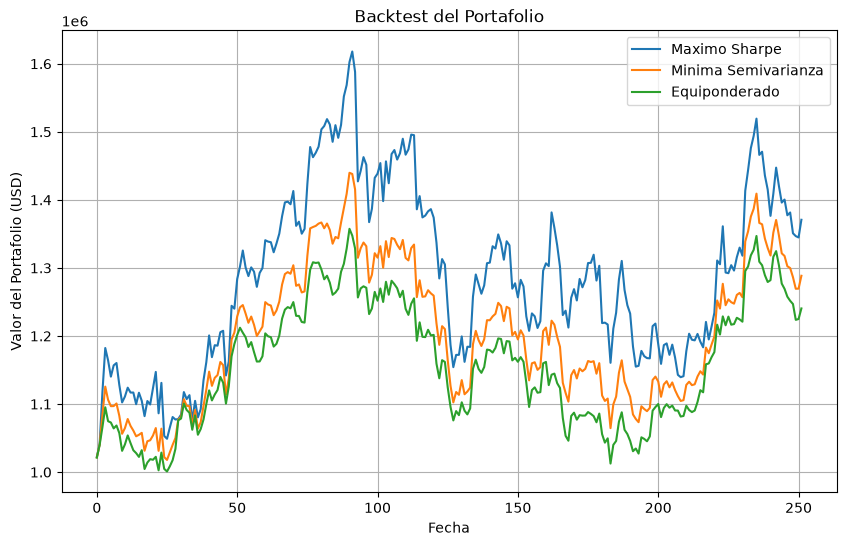

In [17]:
# Garfica del millon de dolares 
plt.figure(figsize=(10, 6))

for name in portfolio_values.columns:
    plt.plot(
        portfolio_values.index,
        portfolio_values[name],
        label=name
    )

plt.title("Backtest del Portafolio")
plt.xlabel("Fecha")
plt.ylabel("Valor del Portafolio (USD)")
plt.legend()
plt.grid()

plt.show()

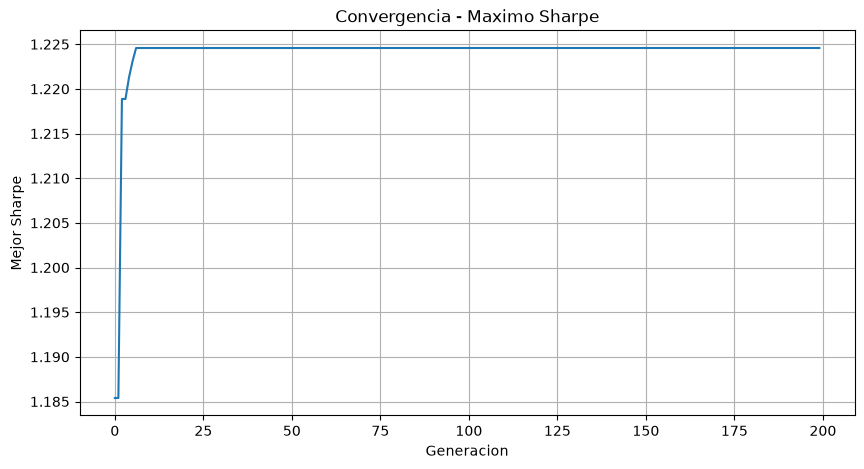

In [18]:
# convergencia del algoritmo genetivo 
plt.figure(figsize=(10, 5))

plt.plot(history_sharpe)

plt.title("Convergencia - Maximo Sharpe")
plt.xlabel("Generacion")
plt.ylabel("Mejor Sharpe")

plt.grid()

plt.show()

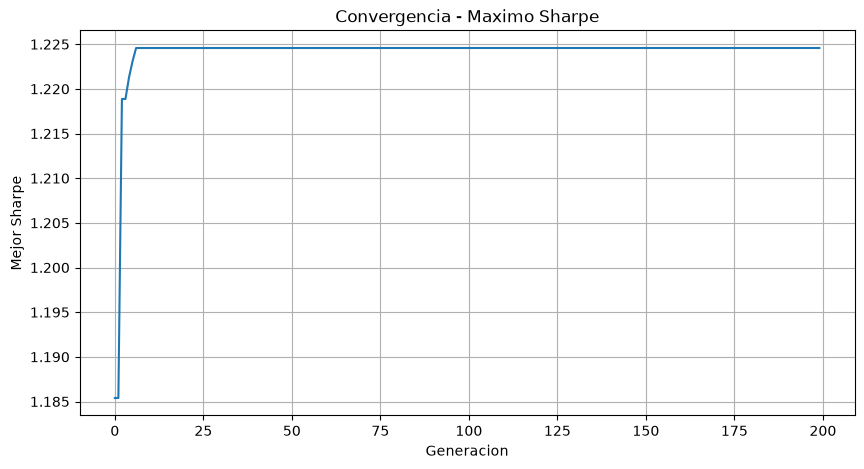

In [19]:
# convergencia de semivarianza 

plt.figure(figsize=(10, 5))

plt.plot(history_sharpe)

plt.title("Convergencia - Maximo Sharpe")
plt.xlabel("Generacion")
plt.ylabel("Mejor Sharpe")

plt.grid()

plt.show()


## FASE 2: TRADING SIMPLE CON MEDIA MÓVIL
Optimización heurística mediante Algoritmo Genético

1. DATOS DE ENTRENAMIENTO

In [20]:
# ====================================================================
# FASE 2: TRADING SIMPLE CON MEDIA MÓVIL
# Optimización heurística mediante Algoritmo Genético
# ====================================================================
# ====================================================================
# 1. DATOS DE ENTRENAMIENTO
# ====================================================================

# Usamos únicamente los precios del periodo TRAIN
train_prices = prices.loc[train_start:train_end]


# Límites de las ventanas de la media móvil
MIN_WINDOW = 5
MAX_WINDOW = 200

LÓGICA DE TRADING

In [21]:
def simular_trading_sma(precios, ventana):
    """
    Simula una estrategia de trading basada en el cruce
    del precio con una Media Móvil Simple (SMA).

    Compra cuando el precio cruza la SMA hacia arriba.
    Venta cuando el precio cruza la SMA hacia abajo.

    Se utiliza la posición del día anterior para evitar
    look-ahead bias.
    """

    # Asegurar que la ventana sea un entero válido
    ventana = int(np.clip(ventana, MIN_WINDOW, MAX_WINDOW))

    # Calcular la Media Móvil Simple
    sma = precios.rolling(window=ventana).mean()
    

    # ------------------------------------------------------------
    # Detectar cruces
    # ------------------------------------------------------------

    # Cruce positivo: el precio pasa de estar debajo
    # a estar por encima de la SMA
    cruce_compra = (
        (precios > sma) &
        (precios.shift(1) <= sma.shift(1))
    )

    # Cruce negativo: el precio pasa de estar encima
    # a estar por debajo de la SMA
    cruce_venta = (
        (precios < sma) &
        (precios.shift(1) >= sma.shift(1))
    )

    # ------------------------------------------------------------
    # Crear posición
    # ------------------------------------------------------------

   # ------------------------------------------------------------
    # Crear posición (VERSIÓN VECTORIZADA OPTIMIZADA)
    # ------------------------------------------------------------
    # Inicializamos con NaN para poder propagar la señal anterior
    posiciones = pd.Series(np.nan, index=precios.index)
    
    # Asignamos 1 en cruces de compra y 0 en cruces de venta
    posiciones.loc[cruce_compra] = 1
    posiciones.loc[cruce_venta] = 0
    
    # ffill() rellena los NaN hacia adelante (mantiene la posición hasta que haya otra señal)
    # fillna(0) asegura que empecemos sin posición (0) antes de la primera señal
    posiciones = posiciones.ffill().fillna(0)

    # ------------------------------------------------------------
    # Rendimientos diarios
    # ------------------------------------------------------------

    retornos_diarios = precios.pct_change()

    # Utilizamos la posición del día anterior
    # para evitar utilizar información futura
    retornos_estrategia = (
        posiciones.shift(1) * retornos_diarios
    )

    return retornos_estrategia.fillna(0)

FUNCIÓN PARA CALCULAR EL RENDIMIENTO DEL PORTAFOLIO

In [22]:
def calcular_rendimiento_trading(pesos, ventanas):
    """
    Calcula los rendimientos diarios del portafolio
    utilizando los pesos y ventanas de SMA proporcionados.
    """

    # Serie donde acumularemos los rendimientos
    retornos_portafolio = pd.Series(
        0.0,
        index=train_prices.index
    )

    # Evaluar cada activo
    for i, ticker in enumerate(tickers):

        # Simular la estrategia para el activo
        retornos_activo = simular_trading_sma(
            train_prices[ticker],
            ventanas[i]
        )

        # Agregar al portafolio según su peso
        retornos_portafolio += (
            retornos_activo * pesos[i]
        )

    return retornos_portafolio

FUNCIÓN FITNESS

In [23]:
def fitness_trading(cromosoma):
    """
    Evalúa cada individuo del Algoritmo Genético.

    Cromosoma:

    [peso_1, peso_2, peso_3,
     ventana_1, ventana_2, ventana_3]

    La función busca maximizar el rendimiento
    considerando el riesgo del portafolio.
    """

    # ------------------------------------------------------------
    # Extraer pesos
    # ------------------------------------------------------------

    pesos = np.array(cromosoma[:3], dtype=float)

    # Evitar división entre cero
    if pesos.sum() <= 0:
        return -1000

    # Normalizar pesos para que sumen 100%
    pesos = pesos / pesos.sum()

    # ------------------------------------------------------------
    # Extraer ventanas
    # ------------------------------------------------------------

    ventanas = np.array(
        cromosoma[3:],
        dtype=int
    )

    ventanas = np.clip(
        ventanas,
        MIN_WINDOW,
        MAX_WINDOW
    )

    # ------------------------------------------------------------
    # Calcular rendimientos
    # ------------------------------------------------------------

    retornos_portafolio = calcular_rendimiento_trading(
        pesos,
        ventanas
    )

    # ------------------------------------------------------------
    # Rendimiento promedio anualizado
    # ------------------------------------------------------------

    rendimiento_promedio = (
        retornos_portafolio.mean() * dias
    )

    # ------------------------------------------------------------
    # Riesgo promedio anualizado
    # ------------------------------------------------------------

    riesgo_promedio = (
        retornos_portafolio.std() * np.sqrt(dias)
    )

    # Penalizar estrategias sin riesgo / sin operaciones
    if riesgo_promedio <= 0:
        return -1000

    # ------------------------------------------------------------
    # Función objetivo
    # ------------------------------------------------------------

    # Se busca obtener el mayor rendimiento
    # considerando el riesgo asumido.
    sharpe = (
        rendimiento_promedio - rf
    ) / riesgo_promedio

    return sharpe

CREAR POBLACIÓN INICIAL

In [24]:

def crear_poblacion_fase2():

    poblacion = []

    for _ in range(population_size):

        # --------------------------------------------------------
        # Pesos del capital
        # --------------------------------------------------------

        pesos = np.random.random(3)

        # Normalizar para que sumen 100%
        pesos = pesos / pesos.sum()

        # --------------------------------------------------------
        # Ventanas de las medias móviles
        # --------------------------------------------------------

        ventanas = np.random.randint(
            MIN_WINDOW,
            MAX_WINDOW + 1,
            3
        )

        # Crear cromosoma
        cromosoma = np.concatenate(
            (pesos, ventanas)
        )

        poblacion.append(cromosoma)

    return np.array(poblacion)

MUTACIÓN


In [25]:
def mutacion_fase2(cromosoma):

    if np.random.random() < mutation_rate:

        # --------------------------------------------------------
        # Mutación de los pesos
        # --------------------------------------------------------

        cambio_pesos = np.random.normal(
            0,
            0.05,
            3
        )

        pesos = np.clip(
            cromosoma[:3] + cambio_pesos,
            0,
            1
        )

        # Evitar que todos sean cero
        if pesos.sum() == 0:
            pesos = np.ones(3)

        # Normalizar
        pesos = pesos / pesos.sum()

        # --------------------------------------------------------
        # Mutación de las ventanas
        # --------------------------------------------------------

        cambio_ventanas = np.random.randint(
            -10,
            11,
            3
        )

        ventanas = cromosoma[3:] + cambio_ventanas

        ventanas = np.clip(
            ventanas,
            MIN_WINDOW,
            MAX_WINDOW
        )

        # Crear nuevo cromosoma
        cromosoma = np.concatenate(
            (pesos, ventanas)
        )

    return cromosoma

CROSSOVER


In [26]:
def crossover_fase2(padre1, padre2):

    hijo = np.zeros(6)

    # ------------------------------------------------------------
    # Crossover de pesos
    # ------------------------------------------------------------

    alpha = np.random.random()

    hijo[:3] = (
        alpha * padre1[:3]
        + (1 - alpha) * padre2[:3]
    )

    # Normalizar pesos
    hijo[:3] = hijo[:3] / hijo[:3].sum()

    # ------------------------------------------------------------
    # Crossover de ventanas
    # ------------------------------------------------------------

    for i in range(3, 6):

        if np.random.random() < 0.5:
            hijo[i] = padre1[i]
        else:
            hijo[i] = padre2[i]

    return hijo

ALGORITMO GENÉTICO

In [27]:

def algoritmo_genetico_fase2():

    # Crear población inicial
    poblacion = crear_poblacion_fase2()

    # Guardar evolución del mejor fitness
    history = []

    # ------------------------------------------------------------
    # Generaciones
    # ------------------------------------------------------------

    for generation in range(generations):

        # Evaluar fitness de cada individuo
        fitness = np.array([
            fitness_trading(individuo)
            for individuo in poblacion
        ])

        # Ordenar de mejor a peor
        orden = np.argsort(fitness)[::-1]

        poblacion = poblacion[orden]
        fitness = fitness[orden]

        # Guardar el mejor resultado
        history.append(fitness[0])

        # Mantener los mejores individuos
        nueva_poblacion = list(
            poblacion[:elite_size]
        )

        # --------------------------------------------------------
        # Crear nuevos individuos
        # --------------------------------------------------------

        while len(nueva_poblacion) < population_size:

            # Seleccionar padres
            padre1 = seleccionar(
                poblacion,
                fitness
            )

            padre2 = seleccionar(
                poblacion,
                fitness
            )

            # Crossover
            hijo = crossover_fase2(
                padre1,
                padre2
            )

            # Mutación
            hijo = mutacion_fase2(hijo)

            # Agregar hijo
            nueva_poblacion.append(hijo)

        # Actualizar población
        poblacion = np.array(nueva_poblacion)

    # ------------------------------------------------------------
    # Obtener mejor individuo final
    # ------------------------------------------------------------

    fitness_final = np.array([
        fitness_trading(individuo)
        for individuo in poblacion
    ])

    mejor_individuo = poblacion[
        np.argmax(fitness_final)
    ]

    return mejor_individuo, history

EJECUTAR OPTIMIZACIÓN

In [28]:
mejor_cromosoma_f2, history_f2 = (
    algoritmo_genetico_fase2()
)

# =============================
# EXTRAER RESULTADOS
# =============================

# Pesos óptimos
pesos_optimos = mejor_cromosoma_f2[:3]

pesos_optimos = (
    pesos_optimos
    / pesos_optimos.sum()
)

# Ventanas óptimas
ventanas_optimas = (
    mejor_cromosoma_f2[3:]
    .astype(int)
)

# Rendimientos finales
retornos_optimos = calcular_rendimiento_trading(
    pesos_optimos,
    ventanas_optimas
)

# Rendimiento anualizado
rendimiento_optimo = (
    retornos_optimos.mean() * dias
)

# Riesgo anualizado
riesgo_optimo = (
    retornos_optimos.std() * np.sqrt(dias)
)

# Sharpe
sharpe_optimo = (
    rendimiento_optimo - rf
) / riesgo_optimo

MOSTRAR RESULTADOS

In [29]:

print("=" * 60)
print("RESULTADOS TRADING SIMPLE")
print("=" * 60)

print("\nParámetros óptimos:")

for i, ticker in enumerate(tickers):

    print(
        f"{ticker}: "
        f"Capital = {pesos_optimos[i] * 100:.2f}% "
        f"(${pesos_optimos[i] * capital:,.2f}) | "
        f"SMA = {ventanas_optimas[i]} días"
    )

print("\nMétricas del portafolio:")
print(
    f"Rendimiento promedio anualizado: "
    f"{rendimiento_optimo * 100:.2f}%"
)

print(
    f"Riesgo promedio anualizado: "
    f"{riesgo_optimo * 100:.2f}%"
)

print(
    f"Sharpe Ratio: "
    f"{sharpe_optimo:.4f}"
)

RESULTADOS TRADING SIMPLE

Parámetros óptimos:
MELI: Capital = 14.53% ($145,289.25) | SMA = 57 días
REGN: Capital = 0.00% ($0.00) | SMA = 155 días
B: Capital = 85.47% ($854,710.75) | SMA = 105 días

Métricas del portafolio:
Rendimiento promedio anualizado: 45.45%
Riesgo promedio anualizado: 14.37%
Sharpe Ratio: 2.9127


TABLA DE RESULTADOS

In [30]:
tabla_resultados = pd.DataFrame({
    "Activo": tickers,
    "Peso Óptimo (%)": pesos_optimos * 100,
    "Capital Inicial ($)": pesos_optimos * capital,
    "Ventana SMA (días)": ventanas_optimas
})

print("\nTabla de resultados:")
display(tabla_resultados)


Tabla de resultados:


,Activo,Peso Óptimo (%),Capital Inicial ($),Ventana SMA (días)
0,MELI,1.452893e+01,145289.253531,57
1,REGN,1.462519e-08,0.000146,155
2,B,8.547107e+01,854710.746323,105


GRÁFICA DE EVOLUCIÓN DEL ALGORITMO GENÉTICO

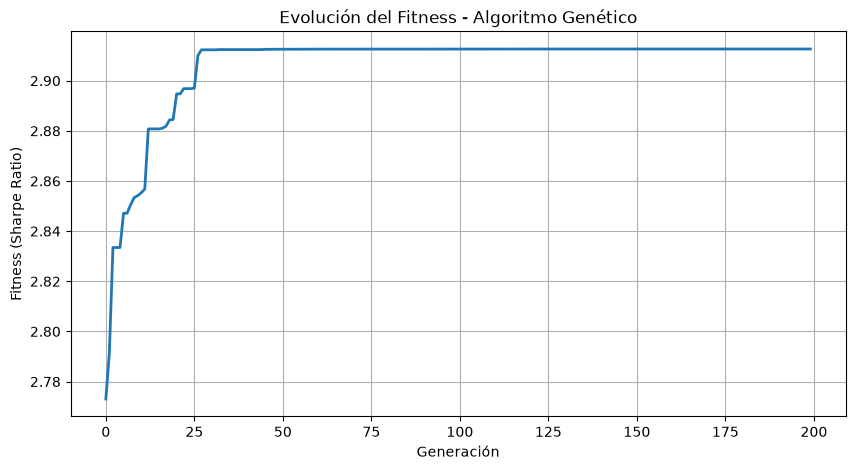

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_f2,
    linewidth=2
)

plt.title(
    "Evolución del Fitness - Algoritmo Genético"
)

plt.xlabel("Generación")
plt.ylabel("Fitness (Sharpe Ratio)")
plt.grid(True)

plt.show()

GRÁFICA DEL BALANCE DEL PORTAFOLIO

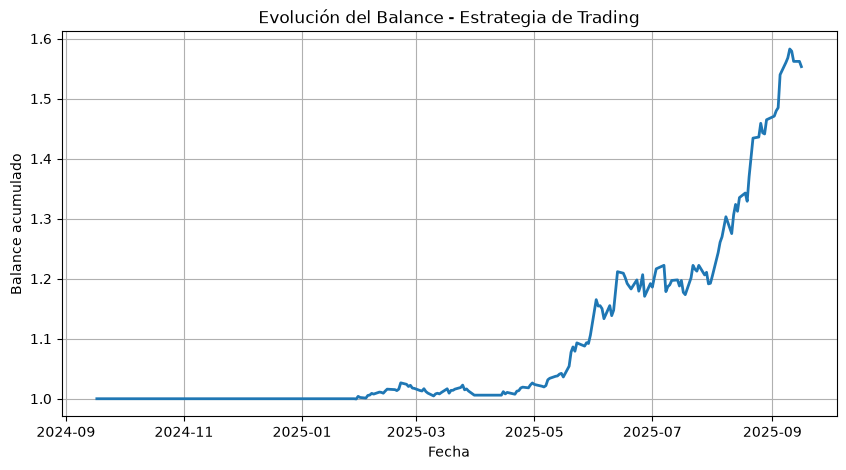

In [32]:
balance = (
    1 + retornos_optimos
).cumprod()

plt.figure(figsize=(10, 5))

plt.plot(
    balance,
    linewidth=2
)

plt.title(
    "Evolución del Balance - Estrategia de Trading"
)

plt.xlabel("Fecha")
plt.ylabel("Balance acumulado")

plt.grid(True)

plt.show()

## Datos con test 

In [33]:
# ============================================================
# VALIDACIÓN FUERA DE MUESTRA (TEST) - FASE 2
# ============================================================
# Usamos la serie completa de precios (train + test) para que
# la SMA ya esté "calentada" con los datos de entrenamiento y
# no perdamos las primeras señales del periodo de test por falta
# de historial (evita el problema de las ventanas "en blanco").

def calcular_rendimiento_trading_completo(pesos, ventanas):
    """
    Igual que calcular_rendimiento_trading, pero usa la serie
    de precios completa (train + test) en lugar de solo train.
    """
    retornos_portafolio = pd.Series(0.0, index=prices.index)

    for i, ticker in enumerate(tickers):
        retornos_activo = simular_trading_sma(
            prices[ticker],
            ventanas[i]
        )
        retornos_portafolio += retornos_activo * pesos[i]

    return retornos_portafolio


# Rendimientos diarios completos, usando los parámetros óptimos
# encontrados por el algoritmo genético (pesos_optimos, ventanas_optimas)
retornos_completos_f2 = calcular_rendimiento_trading_completo(
    pesos_optimos,
    ventanas_optimas
)

# Nos quedamos solo con el periodo TEST
retornos_test_f2 = retornos_completos_f2.loc[test_start:test_end]

print("Observaciones en TEST:", len(retornos_test_f2))

Observaciones en TEST: 252


In [34]:
# ============================================================
# MÉTRICAS EN TEST
# ============================================================
rendimiento_test_f2 = retornos_test_f2.mean() * dias
riesgo_test_f2 = retornos_test_f2.std() * np.sqrt(dias)
sharpe_test_f2 = (rendimiento_test_f2 - rf) / riesgo_test_f2

valor_final_test_f2 = capital * (1 + retornos_test_f2).prod()

print("=" * 60)
print("RESULTADOS TRADING SIMPLE - FUERA DE MUESTRA (TEST)")
print("=" * 60)
print(f"Rendimiento promedio anualizado: {rendimiento_test_f2 * 100:.2f}%")
print(f"Riesgo promedio anualizado:      {riesgo_test_f2 * 100:.2f}%")
print(f"Sharpe Ratio (test):             {sharpe_test_f2:.4f}")
print(f"Capital final (test):            ${valor_final_test_f2:,.2f}")


RESULTADOS TRADING SIMPLE - FUERA DE MUESTRA (TEST)
Rendimiento promedio anualizado: 30.29%
Riesgo promedio anualizado:      33.82%
Sharpe Ratio (test):             0.7893
Capital final (test):            $1,278,113.35


In [35]:
# ============================================================
# TABLA COMPARATIVA TRAIN vs TEST
# ============================================================
valor_final_train_f2 = capital * (1 + retornos_optimos).prod()

comparacion_f2 = pd.DataFrame({
    "Métrica": [
        "Rendimiento anualizado",
        "Riesgo anualizado",
        "Sharpe Ratio",
        "Capital final"
    ],
    "TRAIN": [
        f"{rendimiento_optimo * 100:.2f}%",
        f"{riesgo_optimo * 100:.2f}%",
        f"{sharpe_optimo:.4f}",
        f"${valor_final_train_f2:,.2f}"
    ],
    "TEST": [
        f"{rendimiento_test_f2 * 100:.2f}%",
        f"{riesgo_test_f2 * 100:.2f}%",
        f"{sharpe_test_f2:.4f}",
        f"${valor_final_test_f2:,.2f}"
    ]
})

display(comparacion_f2)

,Métrica,TRAIN,TEST
0,Rendimiento anualizado,45.45%,30.29%
1,Riesgo anualizado,14.37%,33.82%
2,Sharpe Ratio,2.9127,0.7893
3,Capital final,"$1,553,363.60","$1,278,113.35"


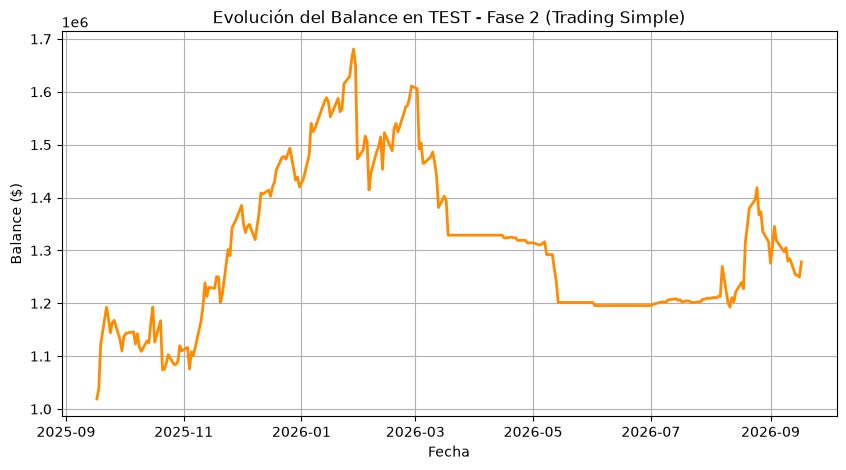

In [36]:
# ============================================================
# GRÁFICA DEL BALANCE EN TEST
# ============================================================
balance_test_f2 = (1 + retornos_test_f2).cumprod() * capital

plt.figure(figsize=(10, 5))

plt.plot(
    balance_test_f2,
    linewidth=2,
    color="darkorange"
)

plt.title("Evolución del Balance en TEST - Fase 2 (Trading Simple)")
plt.xlabel("Fecha")
plt.ylabel("Balance ($)")

plt.grid(True)
plt.show()

## FASE 3: TRADING CON MEDIA MÓVIL PONDERADA (WMA)
Optimización heurística de los pesos de la ventana mediante Algoritmo Genético

**Objetivo de la fase:** mejorar la estrategia de la Fase 2 sustituyendo la media móvil simple (SMA) por una media móvil ponderada (WMA), en la que cada periodo de la ventana recibe un peso propio.

$$WMA_t = \sum_{k=0}^{n-1} w_k \, P_{t-n+1+k}, \qquad w_k \ge 0, \qquad \sum_{k=0}^{n-1} w_k = 1$$

- $w_{n-1}$ pondera el precio más reciente y $w_0$ el más antiguo de la ventana.
- Si $w_k = 1/n$ para todo $k$ se obtiene exactamente la SMA de la Fase 2.
- Se conservan de la Fase 2 el capital asignado a cada activo y la longitud $n$ de cada ventana; lo único que se optimiza son los pesos $w_k$ de cada ventana.

1. Media móvil ponderada, restricción de pesos y función fitness

In [37]:
# ====================================================================
# FASE 3: TRADING CON MEDIA MÓVIL PONDERADA (WMA)
# ====================================================================
from numpy.lib.stride_tricks import sliding_window_view

# Se conservan de la Fase 2: capital por activo (pesos_optimos) y
# longitud de la ventana de cada activo (ventanas_optimas).
longitudes = [int(v) for v in ventanas_optimas]

# REGN recibió ~0% del capital en la Fase 2, por lo que sus pesos de
# ventana no afectan el resultado: solo se optimizan los activos con capital.
UMBRAL_CAPITAL = 0.001
activos_opt = [i for i in range(3) if pesos_optimos[i] > UMBRAL_CAPITAL]


# --------------------------------------------------------------------
# RESTRICCIÓN MATEMÁTICA: pesos >= 0 y suma EXACTAMENTE igual a 1 (100%)
# --------------------------------------------------------------------
def reparar_pesos(w):
    """
    Proyecta un vector cualquiera al simplex:
        w_k >= 0   y   sum(w_k) = 1
    1) Se recortan los negativos a 0.
    2) Se normaliza dividiendo entre la suma.
    3) El residuo de redondeo de punto flotante se absorbe en el peso
       más grande (nunca lo vuelve negativo), de modo que la suma
       queda igual a 1 dentro de la precisión de la máquina.
    """
    w = np.clip(np.asarray(w, dtype=float), 0.0, None)
    if w.sum() <= 0:
        w = np.ones_like(w)
    w = w / w.sum()
    w[np.argmax(w)] += 1.0 - w.sum()
    return w


def dividir_cromosoma(cromosoma):
    """
    Cromosoma = bloques concatenados, uno por activo optimizado:
        [w_MELI(1..n1) | w_B(1..n3)]
    Devuelve una lista con el vector de pesos de la ventana de cada
    activo. Los activos no optimizados usan pesos iguales (SMA).
    Cada bloque se repara, así que la restricción siempre se cumple.
    """
    bloques = [np.full(n, 1.0 / n) for n in longitudes]
    pos = 0
    for i in activos_opt:
        n = longitudes[i]
        bloques[i] = reparar_pesos(cromosoma[pos:pos + n])
        pos += n
    return bloques


# --------------------------------------------------------------------
# MEDIA MÓVIL PONDERADA
# --------------------------------------------------------------------
def calcular_wma(precios, pesos_ventana):
    """
    WMA_t = sum_k  w_k * P_{t-n+1+k},   k = 0..n-1
    w[0] pondera el precio MÁS ANTIGUO de la ventana y w[-1] el MÁS
    RECIENTE. Con w_k = 1/n se obtiene la SMA de la Fase 2.
    """
    n = len(pesos_ventana)
    valores = precios.to_numpy(dtype=float)
    wma = np.full(len(valores), np.nan)
    if len(valores) >= n:
        wma[n - 1:] = sliding_window_view(valores, n) @ pesos_ventana
    return pd.Series(wma, index=precios.index)


def calcular_posiciones_wma(precios, pesos_ventana):
    """
    Posición diaria (1 = invertido, 0 = en efectivo) según la regla de
    cruces de la Fase 2: compra cuando el precio cruza la WMA hacia
    arriba y vende cuando la cruza hacia abajo.
    """
    wma = calcular_wma(precios, pesos_ventana)

    cruce_compra = (precios > wma) & (precios.shift(1) <= wma.shift(1))
    cruce_venta = (precios < wma) & (precios.shift(1) >= wma.shift(1))

    posiciones = pd.Series(np.nan, index=precios.index)
    posiciones.loc[cruce_compra] = 1
    posiciones.loc[cruce_venta] = 0
    return posiciones.ffill().fillna(0)


def simular_trading_wma(precios, pesos_ventana):
    """
    Misma lógica de la Fase 2, pero usando WMA. Se utiliza la posición
    del día anterior para evitar look-ahead bias.
    """
    posiciones = calcular_posiciones_wma(precios, pesos_ventana)
    retornos_estrategia = posiciones.shift(1) * precios.pct_change()
    return retornos_estrategia.fillna(0)


def calcular_rendimiento_wma(precios, pesos_capital, bloques):
    """Rendimiento diario del portafolio con una WMA por activo."""
    retornos = pd.Series(0.0, index=precios.index)
    for i, ticker in enumerate(tickers):
        retornos += simular_trading_wma(precios[ticker], bloques[i]) * pesos_capital[i]
    return retornos


def fitness_wma(cromosoma):
    """Mismo objetivo que la Fase 2 (Sharpe en TRAIN) para poder comparar."""
    bloques = dividir_cromosoma(cromosoma)
    r = calcular_rendimiento_wma(train_prices, pesos_optimos, bloques)
    riesgo = r.std() * np.sqrt(dias)
    if riesgo <= 0:
        return -1000
    return (r.mean() * dias - rf) / riesgo


2. Algoritmo genético para los pesos de la WMA

In [38]:
# ====================================================================
# ALGORITMO GENÉTICO PARA LOS PESOS DE LA WMA
# ====================================================================
def crear_poblacion_fase3():
    poblacion = []

    # Semilla 1: pesos iguales = SMA de la Fase 2 (punto de partida)
    poblacion.append(np.concatenate(
        [np.full(longitudes[i], 1.0 / longitudes[i]) for i in activos_opt]))

    # Semilla 2: WMA lineal clásica (más peso a los precios recientes)
    poblacion.append(np.concatenate(
        [reparar_pesos(np.arange(1, longitudes[i] + 1)) for i in activos_opt]))

    # Resto: pesos aleatorios uniformes sobre el simplex (Dirichlet(1)),
    # que ya suman 1 por construcción
    while len(poblacion) < population_size:
        poblacion.append(np.concatenate(
            [np.random.dirichlet(np.ones(longitudes[i])) for i in activos_opt]))

    return np.array(poblacion)


def crossover_fase3(padre1, padre2):
    """
    Cruce aritmético por bloque: hijo = a*padre1 + (1-a)*padre2.
    Una combinación convexa de dos vectores que suman 1 también suma 1.
    """
    hijo = np.zeros_like(padre1)
    pos = 0
    for i in activos_opt:
        n = longitudes[i]
        a = np.random.random()
        hijo[pos:pos + n] = reparar_pesos(
            a * padre1[pos:pos + n] + (1 - a) * padre2[pos:pos + n])
        pos += n
    return hijo


def mutacion_fase3(cromosoma):
    """
    Ruido gaussiano sobre una fracción de los pesos de cada bloque,
    con desviación proporcional al peso promedio (1/n). Después se
    reparan: sin negativos y suma exacta de 1.
    """
    if np.random.random() < MUT_RATE_F3:
        pos = 0
        for i in activos_opt:
            n = longitudes[i]
            bloque = cromosoma[pos:pos + n].copy()
            mascara = np.random.random(n) < MUT_GENES_F3
            bloque[mascara] += np.random.normal(0, MUT_SIGMA_F3 / n, mascara.sum())
            cromosoma[pos:pos + n] = reparar_pesos(bloque)
            pos += n
    return cromosoma


MUT_RATE_F3 = 0.5     # probabilidad de mutar un individuo
MUT_GENES_F3 = 0.10   # fracción de pesos alterados dentro de un bloque
MUT_SIGMA_F3 = 1.0    # desviación del ruido, en múltiplos del peso medio 1/n


def algoritmo_genetico_fase3():
    poblacion = crear_poblacion_fase3()
    history = []

    for generation in range(generations):
        fitness = np.array([fitness_wma(ind) for ind in poblacion])

        orden = np.argsort(fitness)[::-1]
        poblacion = poblacion[orden]
        fitness = fitness[orden]
        history.append(fitness[0])

        nueva_poblacion = list(poblacion[:elite_size])

        while len(nueva_poblacion) < population_size:
            padre1 = seleccionar(poblacion, fitness)
            padre2 = seleccionar(poblacion, fitness)
            hijo = crossover_fase3(padre1, padre2)
            hijo = mutacion_fase3(hijo)
            nueva_poblacion.append(hijo)

        poblacion = np.array(nueva_poblacion)

    fitness_final = np.array([fitness_wma(ind) for ind in poblacion])
    return poblacion[np.argmax(fitness_final)], history


3. Ejecutar la optimización

In [39]:
# ====================================================================
# EJECUTAR OPTIMIZACIÓN DE LA WMA
# ====================================================================
np.random.seed(42)   # resultados reproducibles independientemente de celdas previas

mejor_cromosoma_f3, history_f3 = algoritmo_genetico_fase3()

# Pesos de ventana óptimos (uno por activo), ya reparados: >= 0 y suma = 1
bloques_optimos = dividir_cromosoma(mejor_cromosoma_f3)

retornos_wma = calcular_rendimiento_wma(train_prices, pesos_optimos, bloques_optimos)

rendimiento_wma = retornos_wma.mean() * dias
riesgo_wma = retornos_wma.std() * np.sqrt(dias)
sharpe_wma = (rendimiento_wma - rf) / riesgo_wma

print("=" * 60)
print("RESULTADOS TRADING CON WMA (TRAIN)")
print("=" * 60)
print(f"Rendimiento promedio anualizado: {rendimiento_wma * 100:.2f}%")
print(f"Riesgo promedio anualizado:      {riesgo_wma * 100:.2f}%")
print(f"Sharpe Ratio:                    {sharpe_wma:.4f}")
print(f"(Fase 2, SMA)                    {sharpe_optimo:.4f}")


RESULTADOS TRADING CON WMA (TRAIN)
Rendimiento promedio anualizado: 46.41%
Riesgo promedio anualizado:      14.40%
Sharpe Ratio:                    2.9718
(Fase 2, SMA)                    2.9127


4. Verificación de la restricción (suma de pesos = 100%) y tabla de resultados

In [40]:
# ====================================================================
# VERIFICACIÓN DE LA RESTRICCIÓN: SUMA DE PESOS = 100%
# ====================================================================
print("Verificación de la restricción  sum(w) = 100%  y  w >= 0\n")

for i, ticker in enumerate(tickers):
    w = bloques_optimos[i]
    suma = w.sum()

    # Si alguna condición falla, el código se detiene
    assert np.all(w >= 0), f"{ticker}: hay pesos negativos"
    assert abs(suma - 1.0) < 1e-12, f"{ticker}: la suma no es 1"

    print(f"{ticker:5s} | {len(w):3d} pesos | suma = {suma * 100:.10f}% "
          f"| mín = {w.min() * 100:.3f}% | máx = {w.max() * 100:.3f}%")

# Tabla de resultados destacados de la Fase 3
filas = []
for i, ticker in enumerate(tickers):
    w = bloques_optimos[i]
    n = len(w)
    k = max(1, n // 5)                       # último 20% de la ventana
    filas.append({
        "Activo": ticker,
        "Capital Inicial ($)": pesos_optimos[i] * capital,
        "Peso capital (%)": pesos_optimos[i] * 100,
        "Ventana (días)": n,
        "Peso del precio más reciente (%)": w[-1] * 100,
        "Peso del último 20% de la ventana (%)": w[-k:].sum() * 100,
        "Optimizado": "Sí" if i in activos_opt else "No (capital ≈ 0)",
    })

tabla_wma = pd.DataFrame(filas)
display(tabla_wma)


Verificación de la restricción  sum(w) = 100%  y  w >= 0

MELI  |  57 pesos | suma = 100.0000000000% | mín = 0.000% | máx = 7.042%
REGN  | 155 pesos | suma = 100.0000000000% | mín = 0.645% | máx = 0.645%
B     | 105 pesos | suma = 100.0000000000% | mín = 0.000% | máx = 2.959%


,Activo,Capital Inicial ($),Peso capital (%),Ventana (días),Peso del precio más reciente (%),Peso del último 20% de la ventana (%),Optimizado
0,MELI,145289.300890,1.452893e+01,57,1.375001,19.112737,Sí
1,REGN,0.000146,1.455685e-08,155,0.645161,20.000000,No (capital ≈ 0)
2,B,854710.698965,8.547107e+01,105,0.864568,19.774931,Sí


5. Gráficas de los pesos óptimos y de la convergencia

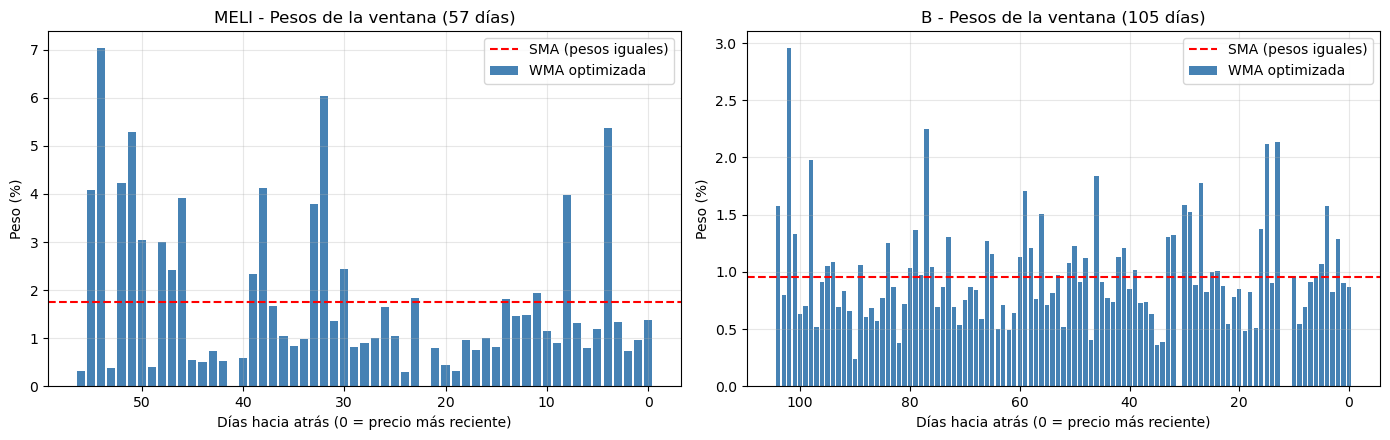

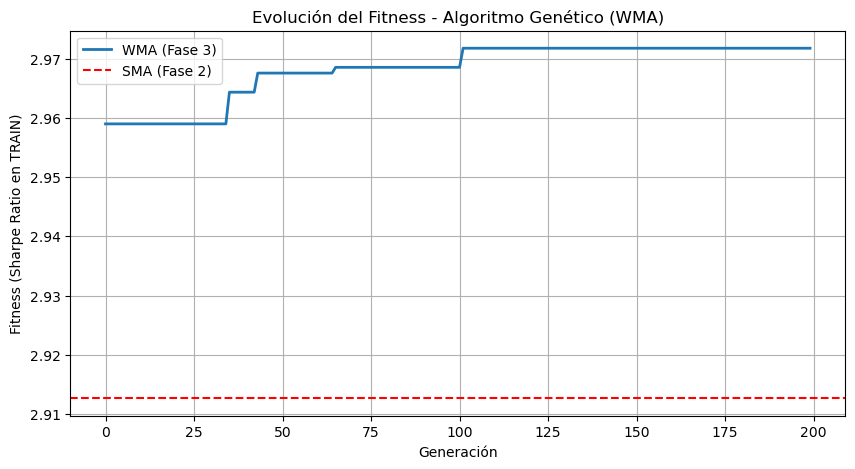

In [41]:
# ====================================================================
# GRÁFICAS: PESOS ÓPTIMOS POR PERIODO DE LA VENTANA
# ====================================================================
fig, ejes = plt.subplots(1, len(activos_opt), figsize=(14, 4.5))
ejes = np.atleast_1d(ejes)

for eje, i in zip(ejes, activos_opt):
    w = bloques_optimos[i]
    n = len(w)
    dias_atras = np.arange(n - 1, -1, -1)      # w[-1] = precio de hoy (0 días atrás)

    eje.bar(dias_atras, w * 100, color="steelblue", label="WMA optimizada")
    eje.axhline(100 / n, color="red", linestyle="--", label="SMA (pesos iguales)")
    eje.set_title(f"{tickers[i]} - Pesos de la ventana ({n} días)")
    eje.set_xlabel("Días hacia atrás (0 = precio más reciente)")
    eje.set_ylabel("Peso (%)")
    eje.invert_xaxis()
    eje.grid(True, alpha=0.3)
    eje.legend()

plt.tight_layout()
plt.show()


# ====================================================================
# CONVERGENCIA DEL ALGORITMO GENÉTICO
# ====================================================================
plt.figure(figsize=(10, 5))
plt.plot(history_f3, linewidth=2, label="WMA (Fase 3)")
plt.axhline(sharpe_optimo, color="red", linestyle="--", label="SMA (Fase 2)")
plt.title("Evolución del Fitness - Algoritmo Genético (WMA)")
plt.xlabel("Generación")
plt.ylabel("Fitness (Sharpe Ratio en TRAIN)")
plt.grid(True)
plt.legend()
plt.show()


6. Validación fuera de muestra (TEST) y comparativa SMA vs. WMA

In [42]:
# ====================================================================
# VALIDACIÓN FUERA DE MUESTRA (TEST) Y COMPARATIVA SMA vs WMA
# ====================================================================
# Referencia: WMA lineal clásica (pesos 1, 2, ..., n) SIN optimizar,
# para saber cuánto aporta realmente el algoritmo genético.
bloques_lineales = [reparar_pesos(np.arange(1, n + 1)) for n in longitudes]

# Rendimientos con la serie completa (train + test) para que la media
# móvil ya esté "calentada" al iniciar el periodo de prueba.
retornos_completos_wma = calcular_rendimiento_wma(prices, pesos_optimos, bloques_optimos)
retornos_completos_lin = calcular_rendimiento_wma(prices, pesos_optimos, bloques_lineales)

retornos_test_wma = retornos_completos_wma.loc[test_start:test_end]
retornos_test_lin = retornos_completos_lin.loc[test_start:test_end]
retornos_train_lin = retornos_completos_lin.loc[train_start:train_end]

estrategias = {
    "Fase 2 - SMA":                 (retornos_optimos,   retornos_test_f2),
    "Fase 3 - WMA lineal (sin GA)": (retornos_train_lin, retornos_test_lin),
    "Fase 3 - WMA optimizada (GA)": (retornos_wma,       retornos_test_wma),
}

filas = []
for nombre, (r_train, r_test) in estrategias.items():
    for periodo, r in (("TRAIN", r_train), ("TEST", r_test)):
        m = metricas(r)
        filas.append({
            "Estrategia": nombre,
            "Periodo": periodo,
            "Rend. anualizado": f"{m['Rendimiento anual'] * 100:.2f}%",
            "Riesgo anualizado": f"{m['Volatilidad'] * 100:.2f}%",
            "Sharpe": round(m["Sharpe"], 4),
            "Max Drawdown": f"{m['Max Drawdown'] * 100:.2f}%",
            "Capital final": f"${capital * (1 + r).prod():,.2f}",
        })

comparacion_f3 = pd.DataFrame(filas)
display(comparacion_f3)


,Estrategia,Periodo,Rend. anualizado,Riesgo anualizado,Sharpe,Max Drawdown,Capital final
0,Fase 2 - SMA,TRAIN,45.45%,14.37%,2.9127,-4.00%,"$1,553,363.67"
1,Fase 2 - SMA,TEST,30.29%,33.82%,0.7893,-29.04%,"$1,278,113.24"
2,Fase 3 - WMA lineal (sin GA),TRAIN,39.77%,18.07%,2.0020,-8.04%,"$1,459,642.55"
3,Fase 3 - WMA lineal (sin GA),TEST,25.77%,34.00%,0.6521,-31.05%,"$1,220,770.46"
4,Fase 3 - WMA optimizada (GA),TRAIN,46.41%,14.40%,2.9718,-4.00%,"$1,568,035.31"
5,Fase 3 - WMA optimizada (GA),TEST,29.17%,33.85%,0.7555,-30.06%,"$1,263,771.60"


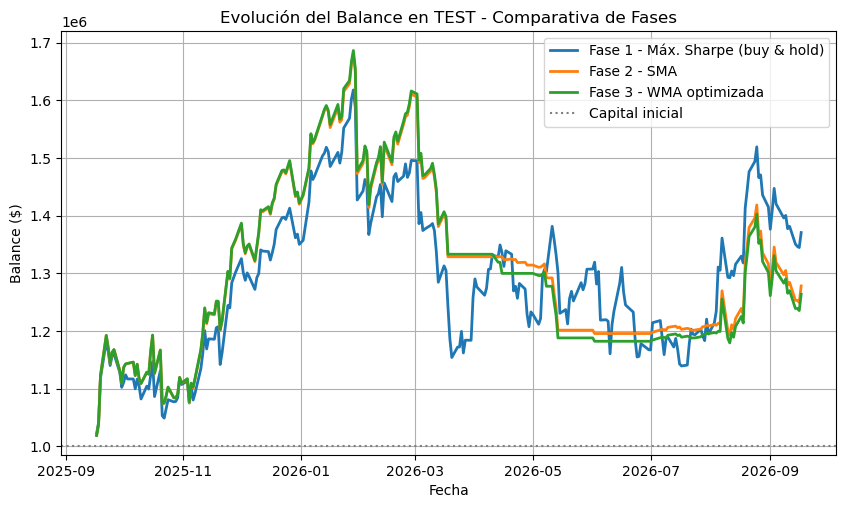

In [43]:
# ====================================================================
# BALANCE EN TEST: FASE 1 vs FASE 2 vs FASE 3
# ====================================================================
idx_test = retornos_test_wma.index

balance_f1 = capital * (1 + pd.Series(portfolio_test_returns["Maximo Sharpe"].values, index=idx_test)).cumprod()
balance_f2 = capital * (1 + retornos_test_f2).cumprod()
balance_f3 = capital * (1 + retornos_test_wma).cumprod()

plt.figure(figsize=(10, 5.5))
plt.plot(balance_f1, linewidth=2, label="Fase 1 - Máx. Sharpe (buy & hold)")
plt.plot(balance_f2, linewidth=2, label="Fase 2 - SMA")
plt.plot(balance_f3, linewidth=2, label="Fase 3 - WMA optimizada")
plt.axhline(capital, color="gray", linestyle=":", label="Capital inicial")
plt.title("Evolución del Balance en TEST - Comparativa de Fases")
plt.xlabel("Fecha")
plt.ylabel("Balance ($)")
plt.grid(True)
plt.legend()
plt.show()


7. Robustez: efecto de las comisiones

Una WMA con pesos irregulares podría cruzar el precio más veces que una SMA y, por tanto, pagar más comisiones. Siguiendo el supuesto del script de apoyo de la materia (`trading_MediaMovil.py`), se repite la simulación en TEST con una comisión de 0.25% por operación.

In [44]:
# ====================================================================
# ROBUSTEZ: EFECTO DE LAS COMISIONES
# ====================================================================
# El script de apoyo de la materia (trading_MediaMovil.py) supone una
# comisión de 0.25% por operación. Una WMA con pesos irregulares puede
# cruzar el precio más veces que una SMA, así que se revisa cuántas
# operaciones genera cada estrategia y cuánto le cuesta la comisión.
COMISION = 0.0025


def calcular_rendimiento_wma_neto(precios, pesos_capital, bloques, comision=COMISION):
    """
    Rendimiento diario del portafolio descontando la comisión. Cada
    compra o venta cuesta 'comision' sobre el capital asignado al activo
    (aproximación: el valor de la posición ≈ su capital inicial).
    Devuelve el rendimiento neto y las operaciones diarias por activo.
    """
    retornos = pd.Series(0.0, index=precios.index)
    operaciones = pd.DataFrame(0.0, index=precios.index, columns=tickers)

    for i, ticker in enumerate(tickers):
        posicion = calcular_posiciones_wma(precios[ticker], bloques[i]).shift(1).fillna(0)
        bruto = posicion * precios[ticker].pct_change().fillna(0)
        cambios = posicion.diff().abs().fillna(posicion.abs())

        retornos += (bruto - comision * cambios) * pesos_capital[i]
        operaciones[ticker] = cambios

    return retornos, operaciones


# La SMA es la WMA con pesos iguales (1/n), así que se evalúa con la
# misma función para que la comparación sea exactamente equivalente.
bloques_sma = [np.full(n, 1.0 / n) for n in longitudes]

configuraciones = {
    "Fase 2 - SMA": bloques_sma,
    "Fase 3 - WMA lineal (sin GA)": bloques_lineales,
    "Fase 3 - WMA optimizada (GA)": bloques_optimos,
}

filas = []
for nombre, bloques in configuraciones.items():
    r_bruto = calcular_rendimiento_wma(prices, pesos_optimos, bloques).loc[test_start:test_end]
    r_neto, ops = calcular_rendimiento_wma_neto(prices, pesos_optimos, bloques)
    r_neto = r_neto.loc[test_start:test_end]
    ops = ops.loc[test_start:test_end]

    m_bruto = metricas(r_bruto)
    m_neto = metricas(r_neto)
    filas.append({
        "Estrategia": nombre,
        "Operaciones en TEST": int(ops[[tickers[i] for i in activos_opt]].sum().sum()),
        "Sharpe sin comisión": round(m_bruto["Sharpe"], 4),
        "Sharpe con comisión": round(m_neto["Sharpe"], 4),
        "Capital final sin comisión": f"${capital * (1 + r_bruto).prod():,.2f}",
        "Capital final con comisión": f"${capital * (1 + r_neto).prod():,.2f}",
    })

comparacion_comision = pd.DataFrame(filas)
print(f"Comisión por operación: {COMISION * 100:.2f}%\n")
display(comparacion_comision)

# Verificación: la SMA evaluada con la función de la Fase 3 reproduce la Fase 2
r_sma_check = calcular_rendimiento_wma(prices, pesos_optimos, bloques_sma).loc[test_start:test_end]
print("\nLa SMA (WMA con pesos iguales) coincide con la Fase 2:",
      np.allclose(r_sma_check, retornos_test_f2))


Comisión por operación: 0.25%



,Estrategia,Operaciones en TEST,Sharpe sin comisión,Sharpe con comisión,Capital final sin comisión,Capital final con comisión
0,Fase 2 - SMA,26,0.7893,0.7401,"$1,278,113.24","$1,257,112.22"
1,Fase 3 - WMA lineal (sin GA),32,0.6521,0.5639,"$1,220,770.46","$1,185,033.33"
2,Fase 3 - WMA optimizada (GA),24,0.7555,0.6871,"$1,263,771.60","$1,235,022.78"



La SMA (WMA con pesos iguales) coincide con la Fase 2: True


8. Resultados destacados y comparativa global

In [45]:
# ====================================================================
# RESULTADOS DESTACADOS: MEDIA MÓVIL Y PONDERACIONES DE AMBOS PORTAFOLIOS
# ====================================================================
resumen_final = pd.DataFrame({
    "Activo": tickers,
    "Fase 1 - Máx. Sharpe (%)": weights_sharpe * 100,
    "Fase 1 - Mín. Semivarianza (%)": weights_semi * 100,
    "Fases 2 y 3 - Capital (%)": pesos_optimos * 100,
    "Ventana (días)": ventanas_optimas,
    "Fase 2 - Tipo de media": "SMA (pesos iguales)",
    "Fase 3 - Tipo de media": "WMA (pesos optimizados)",
})
display(resumen_final)

# ====================================================================
# COMPARATIVA GLOBAL EN TEST (inversión inicial de $1,000,000)
# ====================================================================
filas = []
for _, fila in resultados.iterrows():
    filas.append({
        "Estrategia": "Fase 1 - " + fila["Estrategia"] + " (buy & hold)",
        "Rend. anualizado": fila["Rendimiento anual"],
        "Riesgo": fila["Volatilidad"],
        "Sharpe": fila["Sharpe"],
        "Capital final": fila["Capital Final"],
    })

for nombre, r in (("Fase 2 - SMA", retornos_test_f2),
                  ("Fase 3 - WMA optimizada", retornos_test_wma)):
    m = metricas(r)
    filas.append({
        "Estrategia": nombre,
        "Rend. anualizado": m["Rendimiento anual"],
        "Riesgo": m["Volatilidad"],
        "Sharpe": m["Sharpe"],
        "Capital final": capital * (1 + r).prod(),
    })

comparativa_global = pd.DataFrame(filas)
comparativa_global["Rend. anualizado"] = (comparativa_global["Rend. anualizado"] * 100).map("{:.2f}%".format)
comparativa_global["Riesgo"] = (comparativa_global["Riesgo"] * 100).map("{:.2f}%".format)
comparativa_global["Sharpe"] = comparativa_global["Sharpe"].round(4)
comparativa_global["Capital final"] = comparativa_global["Capital final"].map("${:,.2f}".format)
display(comparativa_global)


,Activo,Fase 1 - Máx. Sharpe (%),Fase 1 - Mín. Semivarianza (%),Fases 2 y 3 - Capital (%),Ventana (días),Fase 2 - Tipo de media,Fase 3 - Tipo de media
0,MELI,2.149456e+01,29.74817,1.452893e+01,57,SMA (pesos iguales),WMA (pesos optimizados)
1,REGN,2.582590e-13,20.97625,1.455685e-08,155,SMA (pesos iguales),WMA (pesos optimizados)
2,B,7.850544e+01,49.27558,8.547107e+01,105,SMA (pesos iguales),WMA (pesos optimizados)


,Estrategia,Rend. anualizado,Riesgo,Sharpe,Capital final
0,Fase 1 - Maximo Sharpe (buy & hold),39.72%,40.41%,0.8939,"$1,370,757.61"
1,Fase 1 - Minima Semivarianza (buy & hold),29.89%,30.16%,0.8718,"$1,288,485.43"
2,Fase 1 - Equiponderado (buy & hold),25.04%,26.46%,0.8103,"$1,240,507.11"
3,Fase 2 - SMA,30.29%,33.82%,0.7893,"$1,278,113.24"
4,Fase 3 - WMA optimizada,29.17%,33.85%,0.7555,"$1,263,771.60"


## Desarrollo y justificación de la Fase 3

### 1. Planteamiento
La Fase 2 encontró, para cada activo, una ventana óptima de media móvil simple (MELI: 57 días, REGN: 155 días, Barrick: 105 días). La SMA da el mismo peso a todos los días de la ventana, de modo que un precio de hace 100 días influye igual que el de ayer. La Fase 3 relaja esa suposición: se conserva la ventana y el capital de la Fase 2, y se busca qué peso debe tener cada periodo de la ventana para que la señal de compra y venta (cruce del precio con la media móvil) sea más rentable respecto al riesgo.

### 2. Justificación de la media móvil ponderada
- La SMA es un caso particular de la WMA ($w_k = 1/n$), por lo que el espacio de búsqueda de la Fase 3 contiene la solución de la Fase 2. Por eso la WMA puede igualar la SMA y solo tiene margen para mejorarla.
- En la práctica se suele dar más importancia a los precios recientes, porque reflejan mejor las condiciones actuales del mercado y la media reacciona más rápido a los cambios de tendencia (Murphy, 1999). En lugar de imponer una forma fija (por ejemplo, la WMA lineal), se deja que el algoritmo heurístico la determine a partir de los datos.
- El problema tiene 57 y 105 variables continuas (una por periodo), con una restricción de igualdad. El fitness se calcula mediante una simulación de trading, que no es derivable y presenta cruces discontinuos. Esto justifica un método heurístico en lugar de uno analítico (Holland, 1975; Goldberg, 1989).

### 3. Diseño del algoritmo genético
| Elemento | Decisión |
|---|---|
| Cromosoma | Bloques concatenados de pesos, uno por activo con capital (MELI y Barrick: 57 + 105 = 162 genes). REGN recibió ≈ 0% del capital en la Fase 2, así que sus pesos no afectan el resultado y se dejan iguales (SMA). |
| Población inicial | 100 individuos: uno con pesos iguales (la SMA de la Fase 2), uno con WMA lineal y el resto aleatorios uniformes sobre el simplex (Dirichlet). |
| Selección | Torneo de 3 individuos (la misma función de las fases anteriores). |
| Cruce | Aritmético por bloque: $hijo = \alpha \cdot padre_1 + (1-\alpha) \cdot padre_2$. |
| Mutación | Con probabilidad 0.5 por individuo, ruido gaussiano sobre el 10% de los pesos de cada bloque. |
| Elitismo | Los 5 mejores pasan intactos a la siguiente generación. |
| Fitness | Sharpe Ratio del portafolio en TRAIN (Sharpe, 1966), igual que en la Fase 2, para que la comparación sea justa. |
| Parámetros | 100 individuos y 200 generaciones (los mismos de las fases anteriores). |

### 4. Restricciones matemáticas (suma de pesos = 100%)
Cada vector de pesos debe cumplir $w_k \ge 0$ y $\sum_k w_k = 1$. La restricción se garantiza en tres niveles:
1. **Reparación:** la función `reparar_pesos` recorta los negativos a cero, normaliza dividiendo entre la suma y absorbe el residuo de redondeo en el peso más grande, sin volverlo negativo.
2. **Operadores cerrados:** el cruce aritmético (combinación convexa de vectores que suman 1) mantiene la suma en 1, y la mutación repara el vector después de perturbarlo.
3. **Decodificación:** antes de calcular el fitness se repara cada bloque, de modo que ningún individuo evaluado puede violar la restricción. Además, `assert` verifica el resultado final: la suma es 100.0000000000% para los tres activos (con la precisión propia del punto flotante).

### 5. Resultados (sin comisiones)
| Estrategia | Periodo | Rend. anualizado | Riesgo | Sharpe | Capital final |
|---|---|---|---|---|---|
| Fase 2 - SMA | TRAIN | 45.45% | 14.37% | 2.9127 | $1,553,364 |
| Fase 3 - WMA optimizada | TRAIN | 46.41% | 14.40% | 2.9718 | $1,568,035 |
| Fase 2 - SMA | TEST | 30.29% | 33.82% | 0.7893 | $1,278,113 |
| Fase 3 - WMA lineal (sin GA) | TEST | 25.77% | 34.00% | 0.6521 | $1,220,770 |
| Fase 3 - WMA optimizada | TEST | 29.17% | 33.85% | 0.7555 | $1,263,772 |

### 6. Discusión
- **En TRAIN** la WMA optimizada mejora ligeramente a la SMA (Sharpe 2.9718 frente a 2.9127). Esto era esperable: la SMA forma parte de la población inicial y el elitismo impide empeorar. La curva de convergencia se estabiliza hacia la generación 100 y el mejor individuo inicial ya tenía un Sharpe de 2.959, por lo que la mejora aportada por el algoritmo es pequeña.
- **En TEST** la mejora no se sostiene: el Sharpe es 0.7555 frente a 0.7893 de la SMA, y el capital final es $14,342 menor (aproximadamente 1.1%). Es una diferencia pequeña, pero en sentido contrario a lo buscado. La WMA lineal, que impone más peso a lo reciente, resulta peor que ambas (0.6521).
- **Causa probable: sobreajuste.** Se ajustan más de 150 parámetros libres con unas 250 observaciones diarias. Los pesos óptimos no muestran un patrón de "más peso a lo reciente": el último 20% de la ventana concentra 19.1% del peso en MELI y 19.8% en Barrick, casi lo mismo que en una SMA (20%). Los pesos parecen ajustar el ruido del periodo de entrenamiento más que una regla con sentido económico.
- **Limitación adicional:** el resultado es de un único periodo de prueba y de una sola ejecución del algoritmo genético. La diferencia entre WMA y SMA en TEST es pequeña y no permite afirmar que una sea mejor que la otra.

### 7. Efecto de las comisiones (0.25% por operación)
| Estrategia | Operaciones en TEST | Sharpe sin / con comisión | Capital final con comisión |
|---|---|---|---|
| Fase 2 - SMA | 26 | 0.7893 / 0.7401 | $1,257,112 |
| Fase 3 - WMA lineal (sin GA) | 32 | 0.6521 / 0.5639 | $1,185,033 |
| Fase 3 - WMA optimizada | 24 | 0.7555 / 0.6871 | $1,235,023 |

La hipótesis de que la WMA optimizada operaría más que la SMA no se cumplió: realiza un número similar de operaciones (24 frente a 26). Aun así, la comisión le cuesta más (unos $28,749 frente a $21,001), por lo que la diferencia a favor de la SMA aumenta al considerar costos. La comisión se aplica como aproximación sobre el capital asignado a cada activo.

### 8. Comparativa global en TEST
Con una inversión inicial de $1,000,000, el portafolio de la Fase 1 de máximo Sharpe mantenido sin operar (buy & hold) termina con $1,370,758 (Sharpe 0.8939), por encima de la estrategia con SMA ($1,278,113) y de la WMA ($1,263,772). Las estrategias de trading sí asumen menos riesgo (33.8% frente a 40.4% de volatilidad), pero en este periodo no compensaron con más rendimiento. Es decir, el trading con media móvil no superó a mantener el portafolio de la Fase 1.

### 9. Conclusión de la fase
El algoritmo heurístico encuentra pesos válidos (no negativos y con suma exacta de 100%) que mejoran el desempeño dentro de la muestra, pero esa mejora no se traslada de forma clara a datos nuevos, y se reduce todavía más al incluir comisiones. Con estos activos y este periodo, la ponderación de la media móvil no aporta una ventaja demostrable sobre la SMA de la Fase 2, y la mayor flexibilidad aumenta el riesgo de sobreajuste. Como posibles mejoras: reducir el número de parámetros (por ejemplo, una ponderación exponencial con un solo parámetro de decaimiento), penalizar pesos poco suaves, o validar con varios periodos de prueba (walk-forward).

## Bibliografía (Fase 3)

**Material de apoyo proporcionado en la materia**
- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *trading_MediaMovil.py* [Código fuente]. Instituto Tecnológico y de Estudios Superiores de Occidente (ITESO). (Regla de trading con media móvil y supuesto de comisión de 0.25% por operación).
- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *funPortafolio.py* [Código fuente]. ITESO. (Cálculo del rendimiento esperado y del riesgo de un portafolio).
- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *desv_esp_activos.py* [Código fuente]. ITESO. (Frontera de Markowitz con tres activos).
- Material didáctico de la materia Métodos de Inteligencia Artificial. (s. f.). *downloadValues.py* [Código fuente]. ITESO. (Descarga de precios históricos).

**Referencias teóricas**
- Goldberg, D. E. (1989). *Genetic algorithms in search, optimization, and machine learning*. Addison-Wesley.
- Holland, J. H. (1975). *Adaptation in natural and artificial systems*. University of Michigan Press.
- Markowitz, H. (1952). Portfolio selection. *The Journal of Finance, 7*(1), 77-91.
- Murphy, J. J. (1999). *Technical analysis of the financial markets*. New York Institute of Finance.
- Sharpe, W. F. (1966). Mutual fund performance. *The Journal of Business, 39*(1), 119-138.

**Herramientas**
- Aroussi, R. (s. f.). *yfinance* [Software]. https://github.com/ranaroussi/yfinance
- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature, 585*, 357-362.
- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.